## regression notes

In [1]:
import pandas as pd
import subprocess
import requests
import numpy as np

In [2]:
df = pd.read_csv('/Users/foroghakbari/Zoomcamp/ml_course/zoomcamp_ml/regression/data.csv')

In [3]:
df.head()
df.columns.str.lower()

Index(['make', 'model', 'year', 'engine fuel type', 'engine hp',
       'engine cylinders', 'transmission type', 'driven_wheels',
       'number of doors', 'market category', 'vehicle size', 'vehicle style',
       'highway mpg', 'city mpg', 'popularity', 'msrp'],
      dtype='object')

In [4]:
df.columns = df.columns.str.lower().str.replace(' ', '_')

In [5]:
df.columns

Index(['make', 'model', 'year', 'engine_fuel_type', 'engine_hp',
       'engine_cylinders', 'transmission_type', 'driven_wheels',
       'number_of_doors', 'market_category', 'vehicle_size', 'vehicle_style',
       'highway_mpg', 'city_mpg', 'popularity', 'msrp'],
      dtype='object')

In [6]:
df.dtypes

make                  object
model                 object
year                   int64
engine_fuel_type      object
engine_hp            float64
engine_cylinders     float64
transmission_type     object
driven_wheels         object
number_of_doors      float64
market_category       object
vehicle_size          object
vehicle_style         object
highway_mpg            int64
city_mpg               int64
popularity             int64
msrp                   int64
dtype: object

In [7]:
df.dtypes[df.dtypes == 'object']

make                 object
model                object
engine_fuel_type     object
transmission_type    object
driven_wheels        object
market_category      object
vehicle_size         object
vehicle_style        object
dtype: object

In [8]:
strings = list(df.dtypes[df.dtypes == 'object'].index)
strings

['make',
 'model',
 'engine_fuel_type',
 'transmission_type',
 'driven_wheels',
 'market_category',
 'vehicle_size',
 'vehicle_style']

In [9]:
for col in strings:
    df[col] = df[col].str.lower().str.replace(' ', '_')

In [10]:
df.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,bmw,1_series_m,2011,premium_unleaded_(required),335.0,6.0,manual,rear_wheel_drive,2.0,"factory_tuner,luxury,high-performance",compact,coupe,26,19,3916,46135
1,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,convertible,28,19,3916,40650
2,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,28,20,3916,36350
3,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,coupe,28,18,3916,29450
4,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,luxury,compact,convertible,28,18,3916,34500


In [11]:
for col in df.columns:
    print(col)
    print(df[col].unique()[:5])
    print(df[col].nunique())
    print()

make
['bmw' 'audi' 'fiat' 'mercedes-benz' 'chrysler']
48

model
['1_series_m' '1_series' '100' '124_spider' '190-class']
914

year
[2011 2012 2013 1992 1993]
28

engine_fuel_type
['premium_unleaded_(required)' 'regular_unleaded'
 'premium_unleaded_(recommended)' 'flex-fuel_(unleaded/e85)' 'diesel']
10

engine_hp
[335. 300. 230. 320. 172.]
356

engine_cylinders
[ 6.  4.  5.  8. 12.]
9

transmission_type
['manual' 'automatic' 'automated_manual' 'direct_drive' 'unknown']
5

driven_wheels
['rear_wheel_drive' 'front_wheel_drive' 'all_wheel_drive'
 'four_wheel_drive']
4

number_of_doors
[ 2.  4.  3. nan]
3

market_category
['factory_tuner,luxury,high-performance' 'luxury,performance'
 'luxury,high-performance' 'luxury' 'performance']
71

vehicle_size
['compact' 'midsize' 'large']
3

vehicle_style
['coupe' 'convertible' 'sedan' 'wagon' '4dr_hatchback']
16

highway_mpg
[26 28 27 25 24]
59

city_mpg
[19 20 18 17 16]
69

popularity
[3916 3105  819  617 1013]
48

msrp
[46135 40650 36350 29450 345

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='msrp', ylabel='Count'>

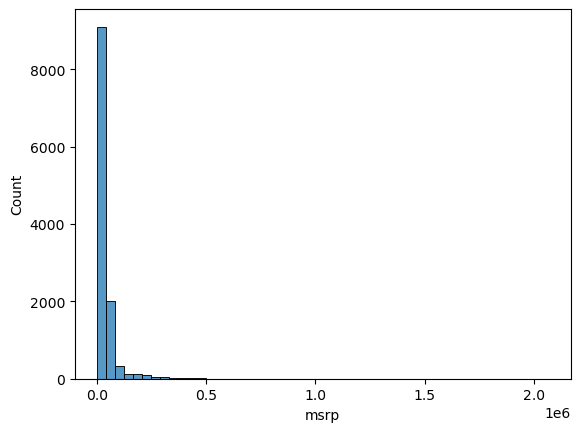

In [13]:
sns.histplot(df.msrp, bins=50)

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='msrp', ylabel='Count'>

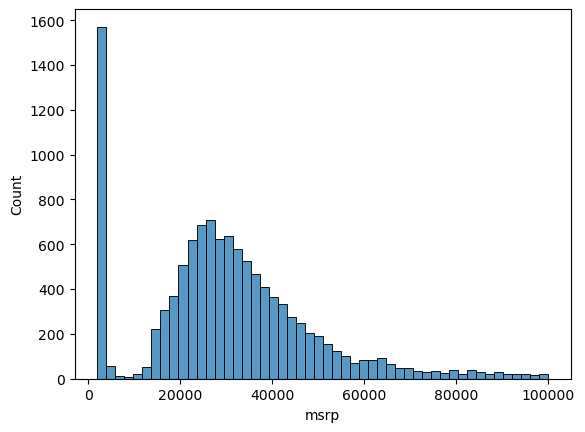

In [14]:
sns.histplot(df.msrp[df.msrp < 100000], bins=50) #to get  a better view of the distribution

In [15]:
np.log([0 + 1, 1 + 1, 10 + 1, 1000 + 1, 100000 + 1])

array([ 0.        ,  0.69314718,  2.39789527,  6.90875478, 11.51293546])

In [16]:
np.log1p([0, 1, 10, 1000, 100000])

array([ 0.        ,  0.69314718,  2.39789527,  6.90875478, 11.51293546])

In [17]:
price_logs = np.log1p(df.msrp)

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='msrp', ylabel='Count'>

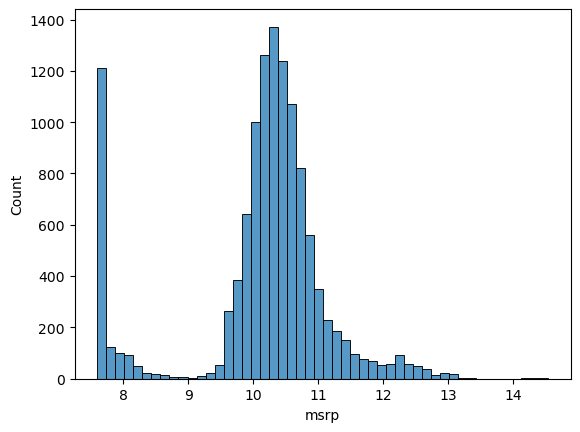

In [18]:
sns.histplot(price_logs, bins=50) #looks more normal distributed

In [19]:
df.isnull().sum()

make                    0
model                   0
year                    0
engine_fuel_type        3
engine_hp              69
engine_cylinders       30
transmission_type       0
driven_wheels           0
number_of_doors         6
market_category      3742
vehicle_size            0
vehicle_style           0
highway_mpg             0
city_mpg                0
popularity              0
msrp                    0
dtype: int64

In [20]:
## training, validation and testing

In [21]:
n =len(df)

In [22]:
n

11914

In [23]:
n_val = int(n * 0.2) #to do a 60/20/20 split- to calculate how many records have 20%
n_test = int(n * 0.2)
n_train = n - n_val - n_test

In [24]:
n, n_val, n_test, n_train

(11914, 2382, 2382, 7150)

In [25]:
df.iloc[:10]

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,bmw,1_series_m,2011,premium_unleaded_(required),335.0,6.0,manual,rear_wheel_drive,2.0,"factory_tuner,luxury,high-performance",compact,coupe,26,19,3916,46135
1,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,convertible,28,19,3916,40650
2,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,28,20,3916,36350
3,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,coupe,28,18,3916,29450
4,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,luxury,compact,convertible,28,18,3916,34500
5,bmw,1_series,2012,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,coupe,28,18,3916,31200
6,bmw,1_series,2012,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,convertible,26,17,3916,44100
7,bmw,1_series,2012,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,28,20,3916,39300
8,bmw,1_series,2012,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,luxury,compact,convertible,28,18,3916,36900
9,bmw,1_series,2013,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,luxury,compact,convertible,27,18,3916,37200


In [26]:
df.iloc[:10]

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,bmw,1_series_m,2011,premium_unleaded_(required),335.0,6.0,manual,rear_wheel_drive,2.0,"factory_tuner,luxury,high-performance",compact,coupe,26,19,3916,46135
1,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,convertible,28,19,3916,40650
2,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,28,20,3916,36350
3,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,coupe,28,18,3916,29450
4,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,luxury,compact,convertible,28,18,3916,34500
5,bmw,1_series,2012,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,coupe,28,18,3916,31200
6,bmw,1_series,2012,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,convertible,26,17,3916,44100
7,bmw,1_series,2012,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,28,20,3916,39300
8,bmw,1_series,2012,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,luxury,compact,convertible,28,18,3916,36900
9,bmw,1_series,2013,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,luxury,compact,convertible,27,18,3916,37200


In [27]:
df_val = df.iloc[:n_val]
df_test = df.iloc[n_val:n_val+n_test]
df_train = df.iloc[n_val+n_test:]

#issue here is that its sequential and not random e.g. all one type of car is at the front etc. so the data is not representative.

In [28]:
df_val

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,bmw,1_series_m,2011,premium_unleaded_(required),335.0,6.0,manual,rear_wheel_drive,2.0,"factory_tuner,luxury,high-performance",compact,coupe,26,19,3916,46135
1,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,convertible,28,19,3916,40650
2,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,28,20,3916,36350
3,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,coupe,28,18,3916,29450
4,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,luxury,compact,convertible,28,18,3916,34500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2377,porsche,cayenne,2016,premium_unleaded_(required),570.0,8.0,automatic,all_wheel_drive,4.0,"crossover,luxury,high-performance",midsize,4dr_suv,21,14,1715,157300
2378,porsche,cayenne,2016,diesel,240.0,6.0,automatic,all_wheel_drive,4.0,"crossover,luxury,diesel",midsize,4dr_suv,29,20,1715,62300
2379,porsche,cayenne,2017,premium_unleaded_(required),520.0,8.0,automatic,all_wheel_drive,4.0,"crossover,luxury,performance",midsize,4dr_suv,21,14,1715,116500
2380,porsche,cayenne,2017,premium_unleaded_(required),300.0,6.0,automatic,all_wheel_drive,4.0,"crossover,luxury",midsize,4dr_suv,24,18,1715,59600


In [29]:
#need to random shuffle, using numpy to shuffle an arbitrary sequence 

idx = np.arange(n)
np.random.shuffle(idx)

In [30]:
df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train+n_val]]
df_test = df.iloc[idx[n_train+n_val:]]

In [31]:
df_val

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
11572,volvo,xc60,2015,regular_unleaded,302.0,4.0,automatic,front_wheel_drive,4.0,"crossover,luxury,performance",midsize,4dr_suv,30,22,870,44050
9034,lexus,sc_300,1998,regular_unleaded,225.0,6.0,automatic,rear_wheel_drive,2.0,"luxury,performance",midsize,coupe,22,17,454,3211
7545,volkswagen,phaeton,2005,premium_unleaded_(recommended),335.0,8.0,automatic,all_wheel_drive,4.0,"luxury,performance",large,sedan,21,14,873,66950
4824,suzuki,forenza,2008,regular_unleaded,127.0,4.0,automatic,front_wheel_drive,4.0,NaN,compact,sedan,28,19,481,15589
9676,mercedes-benz,slk-class,2015,premium_unleaded_(required),201.0,4.0,manual,rear_wheel_drive,2.0,luxury,compact,convertible,32,22,617,43950
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2059,mercedes-benz,c-class,2015,premium_unleaded_(required),302.0,6.0,automatic,all_wheel_drive,2.0,"luxury,performance",compact,coupe,27,19,617,46050
10068,pontiac,sunbird,1993,regular_unleaded,110.0,4.0,manual,front_wheel_drive,2.0,NaN,compact,convertible,32,22,210,2000
8988,hyundai,santa_fe,2015,regular_unleaded,290.0,6.0,automatic,front_wheel_drive,4.0,crossover,midsize,4dr_suv,25,18,1439,34250
5814,chevrolet,impala_limited,2014,flex-fuel_(unleaded/e85),300.0,6.0,automatic,front_wheel_drive,4.0,flex_fuel,large,sedan,30,18,1385,26840


In [32]:
#one more issue- getting different records first car will not be a porsche / gmc- REPRODUCIBLE.
#set a random seed
np.random.seed(2)

idx = np.arange(n)
np.random.shuffle(idx)

In [33]:
len(df_train), len(df_val), len(df_test)

(7150, 2382, 2382)

In [34]:
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

In [35]:
y_train = np.log1p(df_train.msrp.values)
y_val = np.log1p(df_val.msrp.values)
y_test = np.log1p(df_test.msrp.values)

In [36]:
y_train

array([ 7.95050243, 10.36898103,  7.60140233, ..., 10.17736224,
        9.97678448, 10.68168794])

In [37]:
del df_train['msrp']
del df_val['msrp']
del df_test['msrp']

In [38]:
#linear regression

In [39]:
xi = [453, 11, 86]
w0 = 7.17 #intercept/bias term
w = [0.01, 0.04, 0.002]

In [40]:
def linear_regression(xi):
    n = len(xi)

    pred = w0

    for j in range(n):
        pred = pred + w[j] * xi[j]

    return pred

In [41]:
linear_regression(xi)

12.312

In [42]:
#w0 when we have no predictors/know nothing about the car

In [43]:
#log transformation 
np.expm1(12.312)

222347.2221101062

In [44]:
def dot(xi, w):
    n = len(xi)

    res = 0.0

    for j in range(n):
        res = res + xi[j] * w[j]

    return res

In [45]:
def linear_regression(xi):
    return w0 + dot(xi, w)

In [46]:
w_new = [w0] + w

In [47]:
w_new

[7.17, 0.01, 0.04, 0.002]

In [48]:
def linear_regression(xi):
    xi = [1] + xi
    return dot(xi, w_new)

In [49]:
linear_regression(xi)

12.312

In [50]:
xi = [453, 11, 86]
w0 = 7.17 #intercept/bias term
w = [0.01, 0.04, 0.002]

In [51]:
x1  = [1, 148, 24, 1385]
x2  = [1, 132, 25, 2031]
x10 = [1, 453, 11, 86]

X = [x1, x2, x10]
X = np.array(X)

In [52]:
X

array([[   1,  148,   24, 1385],
       [   1,  132,   25, 2031],
       [   1,  453,   11,   86]])

In [53]:
w0 = 7.17
w = [0.01, 0.04, 0.002]
w_new = [w0] + w

In [54]:
#function 
def linear_regression(X):
    return X.dot(w_new)

In [55]:
price=linear_regression(X) #in logs

In [56]:
dollar= np.expm1(price)

In [57]:
dollar

array([237992.82334859, 768348.51018973, 222347.22211011])

In [58]:
#training lM

In [59]:
X = [
    [148, 24, 1385],
    [132, 25, 2031],
    [453, 11, 86],
    [158, 24, 185],
    [172, 25, 201],
    [413, 11, 86],
    [38,  54, 185],
    [142, 25, 431],
    [453, 31, 86],
]
X = np.array(X)

In [60]:
XTX = X.T.dot(X)

In [61]:
XTX

array([[ 696471,   44115,  718540],
       [  44115,    7146,  118803],
       [ 718540,  118803, 6359986]])

In [62]:
#Inverse
XTX_inv = np.linalg.inv(XTX)

In [63]:
XTX.dot(XTX_inv).round(1)

array([[ 1.,  0.,  0.],
       [-0.,  1.,  0.],
       [ 0.,  0.,  1.]])

In [64]:
#target 
y = [100, 200, 150, 250, 100, 200, 150, 250, 120]

In [65]:
#equation 
w_full = XTX_inv.dot(X.T).dot(y)

In [66]:
w_full 

array([0.26190562, 3.06101252, 0.03696909])

In [67]:
ones = np.ones(X.shape[0])
X = np.column_stack([ones, X])
XTX = X.T.dot(X)
XTX_inv = np.linalg.inv(XTX)
w_full = XTX_inv.dot(X.T).dot(y)

In [68]:
w0 = w_full[0]
w = w_full[1:]

In [69]:
w0, w

(300.0677669255554, array([-0.22774253, -2.5769413 , -0.02301206]))

In [70]:
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full[0], w_full[1:]

In [71]:
train_linear_regression(X, y)

LinAlgError: Singular matrix

In [ ]:
## pred for car

In [72]:
df_train.dtypes

make                  object
model                 object
year                   int64
engine_fuel_type      object
engine_hp            float64
engine_cylinders     float64
transmission_type     object
driven_wheels         object
number_of_doors      float64
market_category       object
vehicle_size          object
vehicle_style         object
highway_mpg            int64
city_mpg               int64
popularity             int64
dtype: object

In [73]:
df_train.columns

Index(['make', 'model', 'year', 'engine_fuel_type', 'engine_hp',
       'engine_cylinders', 'transmission_type', 'driven_wheels',
       'number_of_doors', 'market_category', 'vehicle_size', 'vehicle_style',
       'highway_mpg', 'city_mpg', 'popularity'],
      dtype='object')

In [74]:
base = ['engine_hp','engine_cylinders','highway_mpg','city_mpg','popularity']

In [75]:
base

['engine_hp', 'engine_cylinders', 'highway_mpg', 'city_mpg', 'popularity']

In [76]:
X_train = df_train[base].values

In [77]:
X_train

array([[2.200e+02, 8.000e+00, 1.700e+01, 1.200e+01, 5.657e+03],
       [2.000e+02, 4.000e+00, 2.500e+01, 1.900e+01, 5.490e+02],
       [1.650e+02, 6.000e+00, 2.000e+01, 1.500e+01, 1.385e+03],
       ...,
       [2.610e+02, 6.000e+00, 2.000e+01, 1.600e+01, 2.009e+03],
       [2.100e+02, 6.000e+00, 2.000e+01, 1.400e+01, 1.851e+03],
       [2.200e+02, 4.000e+00, 3.400e+01, 2.500e+01, 3.105e+03]])

In [78]:
y_train

array([ 7.95050243, 10.36898103,  7.60140233, ..., 10.17736224,
        9.97678448, 10.68168794])

In [79]:
train_linear_regression(X_train, y_train) #all nans, missing values

(nan, array([nan, nan, nan, nan, nan]))

In [80]:
#fill nans with 0s
df_train[base].isnull().sum()

engine_hp           41
engine_cylinders    16
highway_mpg          0
city_mpg             0
popularity           0
dtype: int64

In [81]:
X_train = df_train[base].fillna(0)
#best way to deal with missing data?

In [82]:
w0, w = train_linear_regression(X_train, y_train) #all nans, missing values

In [83]:
y_pred = w0 + X_train.dot(w)

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: ylabel='Count'>

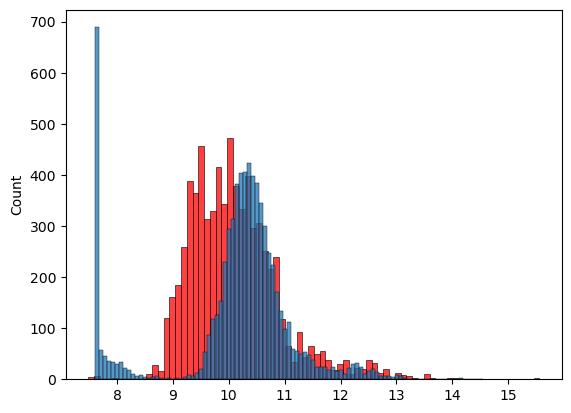

In [84]:
sns.histplot(y_pred, color='red')
sns.histplot(y_train)

In [85]:
#RMSE

In [86]:
#how can we quantify how 'off' predictions are from target y?

In [87]:
def rmse(y, y_pred):
    error = y - y_pred
    se = error **2
    mse= se.mean()
    return np.sqrt(mse)

In [88]:
rmse(y_train, y_pred)

0.7580648382168246

In [89]:
#validation

In [90]:
base = ['engine_hp','engine_cylinders','highway_mpg','city_mpg','popularity']
X_train = df_train[base].fillna(0).values
w0, w = train_linear_regression(X_train, y_train) #all nans, missing values
y_pred = w0 + X_train.dot(w)

In [91]:
def prepare_X(df):
    df_num = df[base]
    df_num = df_num.fillna(0)
    X = df_num.values
    return X

In [92]:
X_train = prepare_X(df_train)

In [93]:
w0, w = train_linear_regression(X_train, y_train) 

X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)
rmse(y_val, y_pred)

0.7451811932611363

In [94]:
rmse(y_val, y_pred)

0.7451811932611363

In [95]:
#feature engineering

In [96]:
df_train.year.max()

2017

In [97]:
def prepare_X(df):
    df = df.copy()
    
    df['age'] = 2017 - df.year
    features = base +['age']
    
    df_num = df[features]
    df_num = df_num.fillna(0)
    X = df_num.values
    return X

In [98]:
X_train = prepare_X(df_train)

In [99]:
X_train

array([[2.200e+02, 8.000e+00, 1.700e+01, 1.200e+01, 5.657e+03, 2.000e+01],
       [2.000e+02, 4.000e+00, 2.500e+01, 1.900e+01, 5.490e+02, 1.000e+00],
       [1.650e+02, 6.000e+00, 2.000e+01, 1.500e+01, 1.385e+03, 2.300e+01],
       ...,
       [2.610e+02, 6.000e+00, 2.000e+01, 1.600e+01, 2.009e+03, 3.000e+00],
       [2.100e+02, 6.000e+00, 2.000e+01, 1.400e+01, 1.851e+03, 8.000e+00],
       [2.200e+02, 4.000e+00, 3.400e+01, 2.500e+01, 3.105e+03, 0.000e+00]])

In [100]:
w0, w = train_linear_regression(X_train, y_train) 

X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)
rmse(y_val, y_pred)

0.5198973637281054

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: ylabel='Count'>

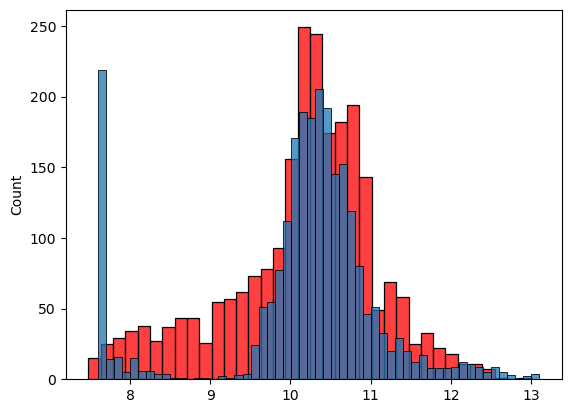

In [101]:
sns.histplot(y_pred, color='red')
sns.histplot(y_val)

In [102]:
#cateogorical variables

In [103]:
#number of doors

In [104]:
df_train

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity
0,ford,f-250,1997,regular_unleaded,220.0,8.0,manual,rear_wheel_drive,3.0,NaN,large,extended_cab_pickup,17,12,5657
1,gmc,canyon,2016,regular_unleaded,200.0,4.0,automatic,four_wheel_drive,4.0,NaN,compact,extended_cab_pickup,25,19,549
2,chevrolet,s-10_blazer,1994,regular_unleaded,165.0,6.0,manual,rear_wheel_drive,4.0,NaN,midsize,4dr_suv,20,15,1385
3,cadillac,catera,2000,regular_unleaded,200.0,6.0,automatic,rear_wheel_drive,4.0,luxury,midsize,sedan,23,16,1624
4,saab,900,1997,regular_unleaded,150.0,4.0,manual,front_wheel_drive,2.0,"hatchback,luxury",compact,2dr_hatchback,26,18,376
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7145,volkswagen,cc,2016,premium_unleaded_(recommended),200.0,4.0,manual,front_wheel_drive,4.0,performance,midsize,sedan,32,21,873
7146,subaru,outback,2015,regular_unleaded,175.0,4.0,automatic,all_wheel_drive,4.0,crossover,midsize,4dr_suv,33,25,640
7147,nissan,xterra,2014,regular_unleaded,261.0,6.0,manual,four_wheel_drive,4.0,NaN,midsize,4dr_suv,20,16,2009
7148,dodge,ram_pickup_1500,2009,regular_unleaded,210.0,6.0,automatic,rear_wheel_drive,2.0,flex_fuel,large,regular_cab_pickup,20,14,1851


In [105]:
df_train['num_doors_2']=(df_train.number_of_doors == 2).astype('int')
df_train['num_doors_4']=(df_train.number_of_doors == 4).astype('int')
df_train['num_doors_4']=(df_train.number_of_doors == 4).astype('int')
df_train['num_doors_4']=(df_train.number_of_doors == 4).astype('int')

In [106]:
for v in [2,3,4]:
    df_train['num_doors_%s' % v] = (df_train.number_of_doors == v).astype('int')
    

In [107]:
df_train 

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,num_doors_2,num_doors_4,num_doors_3
0,ford,f-250,1997,regular_unleaded,220.0,8.0,manual,rear_wheel_drive,3.0,NaN,large,extended_cab_pickup,17,12,5657,0,0,1
1,gmc,canyon,2016,regular_unleaded,200.0,4.0,automatic,four_wheel_drive,4.0,NaN,compact,extended_cab_pickup,25,19,549,0,1,0
2,chevrolet,s-10_blazer,1994,regular_unleaded,165.0,6.0,manual,rear_wheel_drive,4.0,NaN,midsize,4dr_suv,20,15,1385,0,1,0
3,cadillac,catera,2000,regular_unleaded,200.0,6.0,automatic,rear_wheel_drive,4.0,luxury,midsize,sedan,23,16,1624,0,1,0
4,saab,900,1997,regular_unleaded,150.0,4.0,manual,front_wheel_drive,2.0,"hatchback,luxury",compact,2dr_hatchback,26,18,376,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7145,volkswagen,cc,2016,premium_unleaded_(recommended),200.0,4.0,manual,front_wheel_drive,4.0,performance,midsize,sedan,32,21,873,0,1,0
7146,subaru,outback,2015,regular_unleaded,175.0,4.0,automatic,all_wheel_drive,4.0,crossover,midsize,4dr_suv,33,25,640,0,1,0
7147,nissan,xterra,2014,regular_unleaded,261.0,6.0,manual,four_wheel_drive,4.0,NaN,midsize,4dr_suv,20,16,2009,0,1,0
7148,dodge,ram_pickup_1500,2009,regular_unleaded,210.0,6.0,automatic,rear_wheel_drive,2.0,flex_fuel,large,regular_cab_pickup,20,14,1851,1,0,0


In [108]:
def prepare_X(df):
    df = df.copy()
    features = base.copy()

    df['age'] = 2017 - df.year
    features.append('age')

    for v in [2, 3, 4]:
        df['num_doors_%s' % v] = (df.number_of_doors == v).astype('int')
        features.append('num_doors_%s' % v)

    df_num = df[features]
    df_num = df_num.fillna(0)
    X = df_num.values
    return X

In [109]:
X_train = prepare_X(df_train)
w0, w = train_linear_regression(X_train, y_train)

X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)
rmse(y_val, y_pred)

0.5164626483662098

In [110]:
X_train

array([[220.,   8.,  17., ...,   0.,   1.,   0.],
       [200.,   4.,  25., ...,   0.,   0.,   1.],
       [165.,   6.,  20., ...,   0.,   0.,   1.],
       ...,
       [261.,   6.,  20., ...,   0.,   0.,   1.],
       [210.,   6.,  20., ...,   1.,   0.,   0.],
       [220.,   4.,  34., ...,   1.,   0.,   0.]])

In [111]:
df.make.value_counts().head()

make
chevrolet     1123
ford           881
volkswagen     809
toyota         746
dodge          626
Name: count, dtype: int64

In [112]:
makes = list(df.make.value_counts().head().index)

In [113]:
def prepare_X(df):
    df = df.copy()
    features = base.copy()

    df['age'] = 2017 - df.year
    features.append('age')

    for v in [2, 3, 4]:
        df['num_doors_%s' % v] = (df.number_of_doors == v).astype('int')
        features.append('num_doors_%s' % v)
    for v in makes:
        df['make_%s' % v] = (df.make == v).astype('int')
        features.append('make_%s' % v)

    df_num = df[features]
    df_num = df_num.fillna(0)
    X = df_num.values
    return X

In [114]:
X_train = prepare_X(df_train)
w0, w = train_linear_regression(X_train, y_train)

X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)
rmse(y_val, y_pred)

0.5069034840005202

In [115]:
#all cate vars

categorical_variables = [
    'make', 'engine_fuel_type', 'transmission_type', 'driven_wheels',
    'market_category', 'vehicle_size', 'vehicle_style'
]

categories = {}

for c in categorical_variables:
    categories[c] = list(df_train[c].value_counts().head().index)

In [116]:
categories

{'make': ['chevrolet', 'ford', 'volkswagen', 'toyota', 'dodge'],
 'engine_fuel_type': ['regular_unleaded',
  'premium_unleaded_(required)',
  'premium_unleaded_(recommended)',
  'flex-fuel_(unleaded/e85)',
  'diesel'],
 'transmission_type': ['automatic',
  'manual',
  'automated_manual',
  'direct_drive',
  'unknown'],
 'driven_wheels': ['front_wheel_drive',
  'rear_wheel_drive',
  'all_wheel_drive',
  'four_wheel_drive'],
 'market_category': ['crossover',
  'flex_fuel',
  'luxury',
  'luxury,performance',
  'hatchback'],
 'vehicle_size': ['compact', 'midsize', 'large'],
 'vehicle_style': ['sedan',
  '4dr_suv',
  'coupe',
  'convertible',
  '4dr_hatchback']}

In [117]:
def prepare_X(df):
    df = df.copy()
    features = base.copy()

    df['age'] = 2017 - df.year
    features.append('age')

    for v in [2, 3, 4]:
        df['num_doors_%s' % v] = (df.number_of_doors == v).astype('int')
        features.append('num_doors_%s' % v)
    for v in makes:
        df['make_%s' % v] = (df.make == v).astype('int')
        features.append('make_%s' % v)
    
    for c, values in categories.items():
        for v in values:
            df['%s_%s' % (c, v)] = (df[c] == v).astype('int')
            features.append('%s_%s' % (c, v))

    df_num = df[features]
    df_num = df_num.fillna(0)
    X = df_num.values
    return X


In [118]:
X_train = prepare_X(df_train)
w0, w = train_linear_regression(X_train, y_train)

X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)
rmse(y_val, y_pred)

278.2075187171591

In [119]:
w

array([-1.61970786e+00,  1.89961948e+02,  1.54950938e+01,  4.19835303e+00,
       -4.33551917e-02,  2.06122764e-01, -1.60226474e+03, -1.63820061e+03,
       -1.61198398e+03, -1.99325008e+16, -1.71269931e+16,  5.48542521e+16,
        9.50406932e+16,  6.83301681e+17,  1.99325008e+16,  1.71269931e+16,
       -5.48542521e+16, -9.50406932e+16, -6.83301681e+17,  6.70115347e+01,
        6.28271413e+01,  6.17585965e+01,  6.98791636e+01, -2.35051155e+01,
        1.21872567e+16,  1.21872567e+16,  1.21872567e+16,  1.21872567e+16,
        1.21872567e+16, -5.98044689e+15, -5.98044689e+15, -5.98044689e+15,
       -5.98044689e+15,  3.81151990e+00,  5.01904117e+00, -6.50174816e+00,
        2.72005507e+00, -4.88163184e+00, -4.34945942e+01, -2.45538172e+01,
       -2.46734576e+01, -6.13098492e-02,  4.94674940e-02,  1.53074030e-01,
        3.28426931e-01, -1.55678336e-01])

In [120]:
#what went wrong rmse increased.

In [ ]:
#categorical vars to our model ended up with RMSE and weights were big- regularisation as a solution

In [121]:
X = [
    [4, 4, 4],
    [3, 5, 5],
    [5, 1, 1],
    [5, 4, 4],
    [7, 5, 5],
    [4, 5, 5],
]

In [122]:
X = np.array(X)

In [123]:
X

array([[4, 4, 4],
       [3, 5, 5],
       [5, 1, 1],
       [5, 4, 4],
       [7, 5, 5],
       [4, 5, 5]])

In [125]:
XTX=X.T.dot(X) #same values, duplicated and inverse doesnt exist

In [126]:
X = [
    [4, 4, 4],
    [3, 5, 5],
    [5, 1, 1],
    [5, 4, 4],
    [7, 5, 5],
    [4, 5, 5.00000001],
]
X = np.array(X)

In [129]:
XTX=X.T.dot(X) 
XTX

array([[140.        , 111.        , 111.00000004],
       [111.        , 108.        , 108.00000005],
       [111.00000004, 108.00000005, 108.0000001 ]])

In [ ]:
y=[1,2,3,1,2,3]

In [130]:
XTX_inv = np.linalg.inv(XTX)

LinAlgError: Singular matrix

In [ ]:
XTX_inv.dot(X.T).dot(y)

In [131]:
XTX = [
    [1, 2, 2],
    [2, 1, 1],
    [2, 1, 1],
]

In [132]:
XTX = [
    [1, 2, 2],
    [2, 1, 1.0000001],
    [2, 1.0000001, 1],
]

In [133]:
XTX_inv = np.linalg.inv(XTX)

In [134]:
XTX_inv

array([[-3.33333356e-01,  3.33333339e-01,  3.33333339e-01],
       [ 3.33333339e-01, -5.00000008e+06,  4.99999991e+06],
       [ 3.33333339e-01,  4.99999991e+06, -5.00000008e+06]])

To solve this problem, we can add a small number to the diagonal of the matrix. If we add a small number to the diagonal - say 0.01 - the inverse can still be found, and the numbers in it are much more under control. The larger the number we add to the diagonal, the more control we get over the weights.

In [135]:
XTX + np.eye(3)

array([[2.       , 2.       , 2.       ],
       [2.       , 2.       , 1.0000001],
       [2.       , 1.0000001, 2.       ]])

In [136]:
XTX = XTX + 0.01 * np.eye(3)

In [137]:
XTX_inv = np.linalg.inv(XTX)

In [138]:
XTX_inv

array([[ -0.33668908,   0.33501399,   0.33501399],
       [  0.33501399,  49.91590897, -50.08509104],
       [  0.33501399, -50.08509104,  49.91590897]])

In [167]:
def train_linear_regression_reg(X, y, r=0.001):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X) #regularisation
    XTX = XTX + r * np.eye(XTX.shape[0])

    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full[0], w_full[1:]

In [144]:
X_train = prepare_X(df_train)
w0, w = train_linear_regression_reg(X_train, y_train, r=0.001)

X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)
rmse(y_val, y_pred)

0.45580666021266875

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: ylabel='Count'>

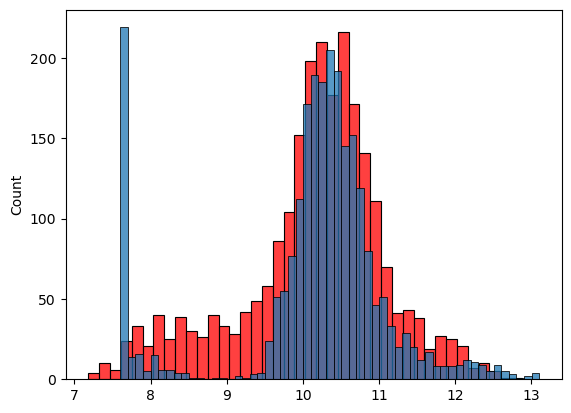

In [145]:
sns.histplot(y_pred, color='red')
sns.histplot(y_val)

In [ ]:
##finding regularisation params for tuning

In [146]:
for r in [0.0, 0.00001, 0.0001, 0.001, 0.1, 1, 10]:
    X_train = prepare_X(df_train)
    w0, w = train_linear_regression_reg(X_train, y_train, r=r)

    X_val = prepare_X(df_val)
    y_pred = w0 + X_val.dot(w)
    score = rmse(y_val, y_pred)

    print(r, w0, score) #diff values of r to applied to the model

0.0 -6206809800533661.0 278.2075187171591
1e-05 7.673787007611165 0.4558068257663136
0.0001 6.310264901074365 0.45580679430756427
0.001 6.3026157604045885 0.45580666021266875
0.1 6.143909793248425 0.4558258323606277
1 5.439126099464934 0.4567485883827313
10 4.225123712318344 0.4680560687034609


What we see: for zero regularization the bias term is huge and the RMSE is huge too - 266. That is the broken model with the duplicated columns problem. But for even a little bit of regularization it improves immediately, and after that the score doesn't really change that much. It starts to become a bit worse as we increase the regularization, and when it's 10 it's even worse.

In [ ]:
#smaller vias is 0.001

In [147]:
r = 0.001
X_train = prepare_X(df_train)
w0, w = train_linear_regression_reg(X_train, y_train, r=r)

X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)
score = rmse(y_val, y_pred)
score

0.45580666021266875

In [ ]:
#using the model

for the final model we do something different: we combine the training and validation datasets into one - let's call it full_train - train the model on all of it, and then make the final evaluation on the test dataset.

In [148]:
df_full_train = pd.concat([df_train, df_val])

In [149]:
df_full_train

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,num_doors_2,num_doors_4,num_doors_3
0,ford,f-250,1997,regular_unleaded,220.0,8.0,manual,rear_wheel_drive,3.0,NaN,large,extended_cab_pickup,17,12,5657,0.0,0.0,1.0
1,gmc,canyon,2016,regular_unleaded,200.0,4.0,automatic,four_wheel_drive,4.0,NaN,compact,extended_cab_pickup,25,19,549,0.0,1.0,0.0
2,chevrolet,s-10_blazer,1994,regular_unleaded,165.0,6.0,manual,rear_wheel_drive,4.0,NaN,midsize,4dr_suv,20,15,1385,0.0,1.0,0.0
3,cadillac,catera,2000,regular_unleaded,200.0,6.0,automatic,rear_wheel_drive,4.0,luxury,midsize,sedan,23,16,1624,0.0,1.0,0.0
4,saab,900,1997,regular_unleaded,150.0,4.0,manual,front_wheel_drive,2.0,"hatchback,luxury",compact,2dr_hatchback,26,18,376,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2377,mercedes-benz,c-class,2015,premium_unleaded_(required),302.0,6.0,automatic,all_wheel_drive,2.0,"luxury,performance",compact,coupe,27,19,617,NaN,NaN,NaN
2378,pontiac,sunbird,1993,regular_unleaded,110.0,4.0,manual,front_wheel_drive,2.0,NaN,compact,convertible,32,22,210,NaN,NaN,NaN
2379,hyundai,santa_fe,2015,regular_unleaded,290.0,6.0,automatic,front_wheel_drive,4.0,crossover,midsize,4dr_suv,25,18,1439,NaN,NaN,NaN
2380,chevrolet,impala_limited,2014,flex-fuel_(unleaded/e85),300.0,6.0,automatic,front_wheel_drive,4.0,flex_fuel,large,sedan,30,18,1385,NaN,NaN,NaN


In [150]:
df_full_train = df_full_train.reset_index(drop=True)

In [151]:
df_full_train

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,num_doors_2,num_doors_4,num_doors_3
0,ford,f-250,1997,regular_unleaded,220.0,8.0,manual,rear_wheel_drive,3.0,NaN,large,extended_cab_pickup,17,12,5657,0.0,0.0,1.0
1,gmc,canyon,2016,regular_unleaded,200.0,4.0,automatic,four_wheel_drive,4.0,NaN,compact,extended_cab_pickup,25,19,549,0.0,1.0,0.0
2,chevrolet,s-10_blazer,1994,regular_unleaded,165.0,6.0,manual,rear_wheel_drive,4.0,NaN,midsize,4dr_suv,20,15,1385,0.0,1.0,0.0
3,cadillac,catera,2000,regular_unleaded,200.0,6.0,automatic,rear_wheel_drive,4.0,luxury,midsize,sedan,23,16,1624,0.0,1.0,0.0
4,saab,900,1997,regular_unleaded,150.0,4.0,manual,front_wheel_drive,2.0,"hatchback,luxury",compact,2dr_hatchback,26,18,376,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9527,mercedes-benz,c-class,2015,premium_unleaded_(required),302.0,6.0,automatic,all_wheel_drive,2.0,"luxury,performance",compact,coupe,27,19,617,NaN,NaN,NaN
9528,pontiac,sunbird,1993,regular_unleaded,110.0,4.0,manual,front_wheel_drive,2.0,NaN,compact,convertible,32,22,210,NaN,NaN,NaN
9529,hyundai,santa_fe,2015,regular_unleaded,290.0,6.0,automatic,front_wheel_drive,4.0,crossover,midsize,4dr_suv,25,18,1439,NaN,NaN,NaN
9530,chevrolet,impala_limited,2014,flex-fuel_(unleaded/e85),300.0,6.0,automatic,front_wheel_drive,4.0,flex_fuel,large,sedan,30,18,1385,NaN,NaN,NaN


In [152]:
X_full_train = prepare_X(df_full_train)

In [153]:
X_full_train

array([[220.,   8.,  17., ...,   0.,   0.,   0.],
       [200.,   4.,  25., ...,   0.,   0.,   0.],
       [165.,   6.,  20., ...,   0.,   0.,   0.],
       ...,
       [290.,   6.,  25., ...,   0.,   0.,   0.],
       [300.,   6.,  30., ...,   0.,   0.,   0.],
       [150.,   4.,  24., ...,   0.,   0.,   0.]])

In [154]:
y_full_train = np.concatenate([y_train, y_val])

In [155]:
y_full_train

array([ 7.95050243, 10.36898103,  7.60140233, ..., 10.44147104,
       10.19768585,  9.70692507])

In [156]:
w0, w = train_linear_regression_reg(X_full_train, y_full_train, r=0.001)

In [157]:
w0

6.307897687586406

In [159]:
X_test = prepare_X(df_test)
y_pred = w0 + X_test.dot(w)
score = rmse(y_test, y_pred)
score

0.46836403872945787

In [160]:
#predicting price of car

In [161]:
car = df_test.iloc[20].to_dict()
car

{'make': 'porsche',
 'model': 'cayenne',
 'year': 2015,
 'engine_fuel_type': 'premium_unleaded_(required)',
 'engine_hp': 520.0,
 'engine_cylinders': 8.0,
 'transmission_type': 'automatic',
 'driven_wheels': 'all_wheel_drive',
 'number_of_doors': 4.0,
 'market_category': 'crossover,luxury,performance',
 'vehicle_size': 'midsize',
 'vehicle_style': '4dr_suv',
 'highway_mpg': 21,
 'city_mpg': 14,
 'popularity': 1715}

In [162]:
df_small = pd.DataFrame([car])
X_small = prepare_X(df_small)

In [163]:
X_small

array([[5.200e+02, 8.000e+00, 2.100e+01, 1.400e+01, 1.715e+03, 2.000e+00,
        0.000e+00, 0.000e+00, 1.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 1.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        1.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 1.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 1.000e+00, 0.000e+00, 0.000e+00,
        1.000e+00, 0.000e+00, 0.000e+00, 0.000e+00]])

In [164]:
y_pred = w0 + X_small.dot(w)
y_pred = y_pred[0]
y_pred

11.857228445952575

In [165]:
np.expm1(y_pred)

141099.60787586603

In [166]:
np.expm1(y_test[20])

113599.99999999991